In [2]:
pip install scikit-fuzzy


   ---------------------------------------- 0.0/920.8 kB ? eta -:--:--
   ---------------------------------------- 920.8/920.8 kB 6.0 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


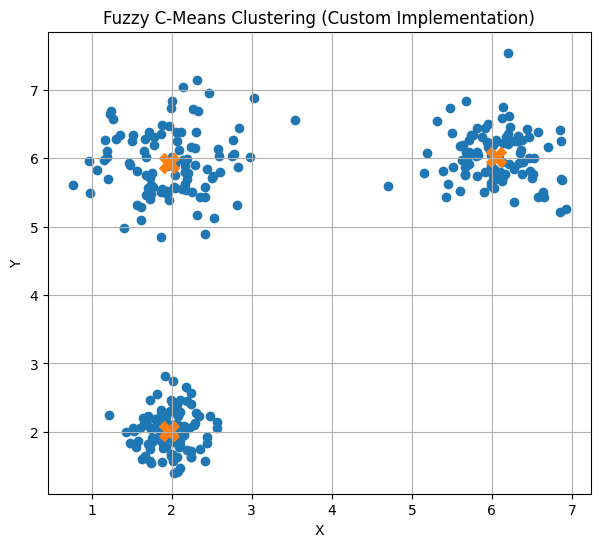

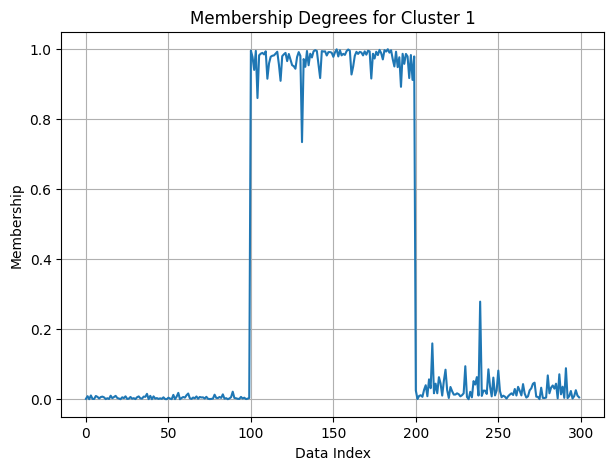

np.float64(0.9385160729119724)

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Generate sample data
np.random.seed(42)
cluster1 = np.random.normal(loc=[2, 2], scale=0.3, size=(100, 2))
cluster2 = np.random.normal(loc=[6, 6], scale=0.4, size=(100, 2))
cluster3 = np.random.normal(loc=[2, 6], scale=0.5, size=(100, 2))

data = np.vstack((cluster1, cluster2, cluster3))
N = data.shape[0]
C = 3                # number of clusters
m = 2.0              # fuzziness

# Initialize membership matrix randomly
u = np.random.dirichlet(np.ones(C), size=N)

def update_centers(u, data, m):
    um = u ** m
    return (um.T @ data) / np.sum(um.T, axis=1, keepdims=True)

def update_membership(centers, data, m):
    dist = np.zeros((N, C))
    for i in range(C):
        dist[:, i] = np.linalg.norm(data - centers[i], axis=1)
    dist = np.fmax(dist, 1e-6)  # avoid division by zero

    power = 2 / (m - 1)
    inv_dist = dist ** (-power)
    u_new = inv_dist / np.sum(inv_dist, axis=1, keepdims=True)
    return u_new

# Loop
for _ in range(50):
    centers = update_centers(u, data, m)
    u = update_membership(centers, data, m)

# Hard labels
labels = np.argmax(u, axis=1)

# Plot clusters
plt.figure(figsize=(7, 6))
plt.scatter(data[:, 0], data[:, 1])
plt.scatter(centers[:, 0], centers[:, 1], marker='X', s=200)
plt.title("Fuzzy C-Means Clustering (Custom Implementation)")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

# Plot membership degrees of cluster 1
plt.figure(figsize=(7, 5))
plt.plot(u[:, 0])
plt.title("Membership Degrees for Cluster 1")
plt.xlabel("Data Index")
plt.ylabel("Membership")
plt.grid(True)
plt.show()

# Fuzzy Partition Coefficient
fpc = np.sum(u**2) / N
fpc
